# Point simulation (Monte-Carlo rollout)
Runs the full integrated-voltage controller (all three noise sources at 0.5),
then performs a Monte-Carlo "branch point" experiment: at t = 20 s the state is
frozen and re-simulated 100 times under independent noise and compared against a
single deterministic (noise-free) rollout. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

In [4]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([           # spike-to-force map  
    [0.0, 0.0],
    [2.0, -2.0]          # N1 spikes velocity with +2 and N2 spikes velocity with -2
])


C  = np.diag([20.0, 1.0])      # cost weights: position penalised 20x more than velocity

T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
t_eval = np.arange(0, T, dt)
f  = 0.1                 # predictive horizon (s)
mu = 0.1                 # spike cost
z_schedule = [(5.0, 5.0), (15.0, 10.0), (30.0, 15.0)]     # (time, target) steps
x0 = [0.0, 0.0]

Af = expm(A * f)
G  = B.T @ Af.T @ C

thresholds = np.zeros(B.shape[1])
# Spike threshold per neuron
for i in range(B.shape[1]):
    thresholds[i] = 0.5 * B[:, i] @ Af.T @ C @ Af @ B[:, i] + mu


F_mat = G @ Af @ (A + np.eye(A.shape[0]))   # how the (predicted) state pulls the drive down
Omega = G @ Af @ B                          # self-reset applied when a neuron spikes


sigma_m = 0.5    # measurement noise
sigma_v = 0.5    # voltage noise
sigma_p = 0.5    # process noise

# low-pass filter the step schedule into a smooth reference z(t)
def get_target(t, z_prev, dt):
    z_base = 0.0
    for t_point, val in z_schedule:
        if t >= t_point:
            z_base = val
    return z_prev + dt * 0.5 * (z_base - z_prev)

In [5]:
N  = B.shape[1]
nT = len(t_eval)

x         = np.zeros((nT, 2))
z         = np.zeros(nT)
V_arr     = np.zeros((nT, N))
s_history = np.zeros((nT, N))

x[0]   = x0
V_arr[0] = G @ (np.array([z[0], 0.0]) - Af @ x[0])

for i in range(nT - 1):
    z[i+1]     = get_target(t_eval[i], z[i], dt)
    target_vec = np.array([z[i], 0.0])                              # desired [position, velocity]

    z_base_i = 0.0
    for t_point, val in z_schedule:
        if t_eval[i] >= t_point:
            z_base_i = val
    target_dot_vec = np.array([0.5 * (z_base_i - z[i]), 0.0])       # ż: rate of change of the reference

    x_measured = x[i] + sigma_m * np.random.standard_normal(N)      # noisy state estimate

    V_current  = V_arr[i]
    difference = V_current - thresholds
    s = np.zeros(N)
    if difference.max() > 0:
        s[np.argmax(difference)] = 1.0                              # winner-take-all: one spike for the best neuron
    s_history[i] = s

    noise_p    = sigma_p * np.random.standard_normal(N) * np.sqrt(dt)
    x[i+1]    = x[i] + dt * (A @ x[i]) + B @ s + noise_p           # noisy plant update

    # leaky-integrator voltage dynamics with spike-driven reset (−Ω·s) and voltage noise
    V_dot      = (-V_current + G @ (target_dot_vec + target_vec) - F_mat @ x_measured)
    V_arr[i+1] = (V_current + dt * V_dot - Omega @ s + sigma_v * np.sqrt(dt) * np.random.standard_normal(N))


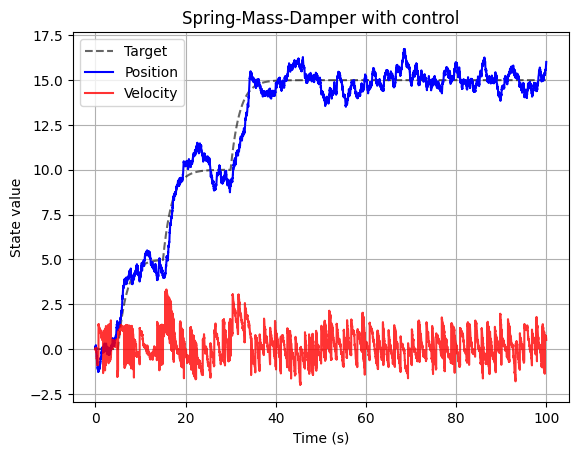

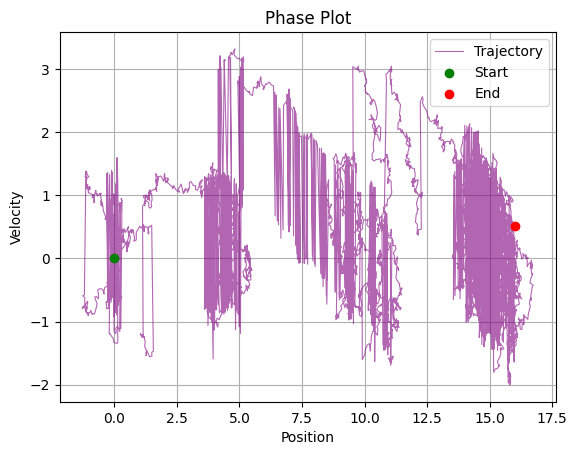

In [6]:
plt.plot(t_eval, z, 'k--', alpha=0.6, label="Target")
plt.plot(t_eval, x[:, 0], color='blue',  label="Position")
plt.plot(t_eval, x[:, 1], color='red', alpha=0.8, label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.title("Spring-Mass-Damper with control")
plt.legend()
plt.grid()
plt.show()


plt.figure()
plt.plot(x[:, 0], x[:, 1], color='purple', alpha=0.6, linewidth=0.8, label="Trajectory")
plt.scatter(x[0, 0], x[0, 1], color='green', zorder=5, label="Start")
plt.scatter(x[-1, 0], x[-1, 1], color='red', zorder=5, label="End")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Phase Plot")
plt.legend()
plt.grid()
plt.show()



Total spikes:           611
  Neuron breakdown:     [337 274]
Cumulative error:       51.947
Efficiency ratio:       11.7621  spikes / error-unit


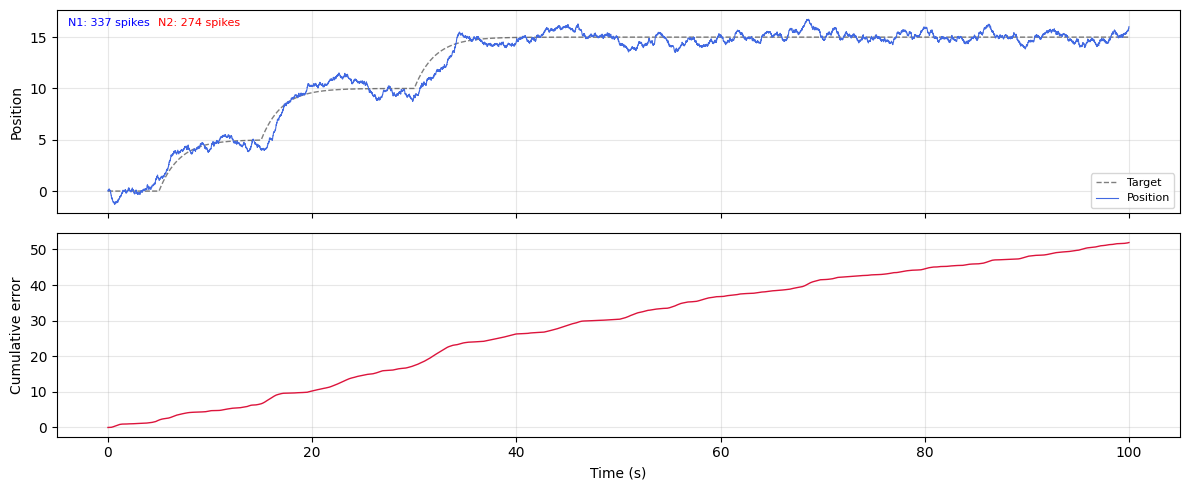

In [7]:
position_error = np.abs(x[:, 0] - z)
cumulative_error = np.cumsum(position_error) * dt

spike_counts = s_history.sum(axis=0).astype(int)
total_spikes  = spike_counts.sum()

final_cumulative_error = cumulative_error[-1]
efficiency_ratio = total_spikes / final_cumulative_error

print(f"Total spikes:           {total_spikes}")
print(f"  Neuron breakdown:     {spike_counts}")
print(f"Cumulative error:       {final_cumulative_error:.3f}")
print(f"Efficiency ratio:       {efficiency_ratio:.4f}  spikes / error-unit")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t_eval, z,       'k--', alpha=0.5, linewidth=1,   label='Target')
axes[0].plot(t_eval, x[:, 0], color='royalblue', linewidth=0.8, label='Position')
axes[0].set_ylabel('Position')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(t_eval, cumulative_error, color='crimson', linewidth=1)
axes[1].set_ylabel('Cumulative error')
axes[1].set_xlabel('Time (s)')
axes[1].grid(alpha=0.3)

for j, c in enumerate(spike_counts):
    axes[0].text(0.01 + j * 0.08, 0.92, f'N{j+1}: {c} spikes',
                 transform=axes[0].transAxes, fontsize=8,
                 color=['blue', 'red'][j])

plt.tight_layout()
plt.show()

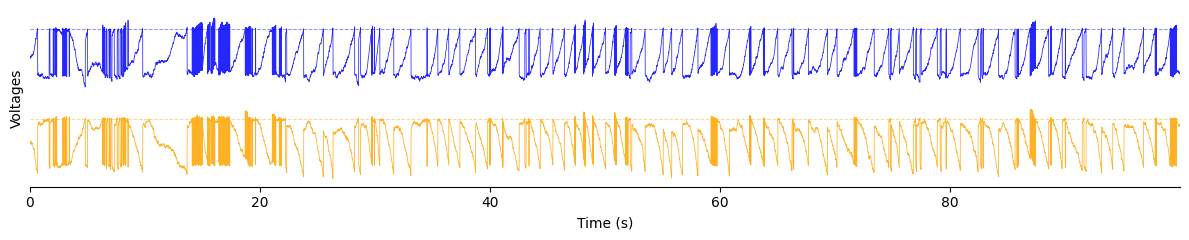

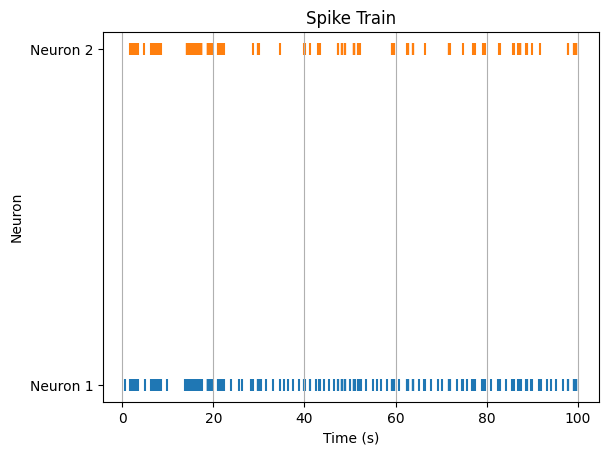

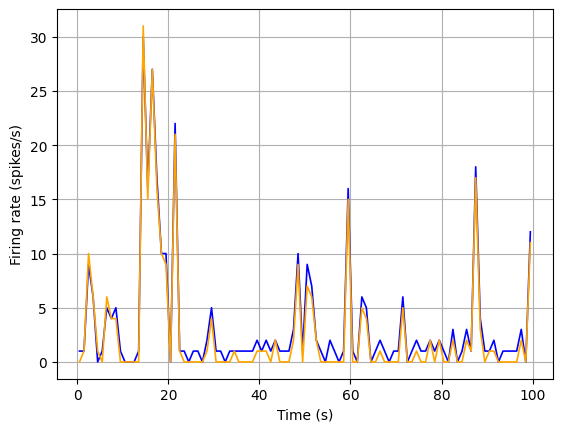

In [8]:
colors = ['blue', 'orange']

gap    = 5
fig, ax = plt.subplots(figsize=(12, 2.5))

for j in range(N):
    v = V_arr[:, j]
    v_norm = (v - np.mean(v)) / (np.std(v) + 1e-9)  
    offset = (N - 1 - j) * gap 
    ax.plot(t_eval, v_norm + offset,
            color=colors[j % len(colors)], linewidth=0.55, alpha=0.85)
    thr_norm = (thresholds[j] - np.mean(v)) / (np.std(v) + 1e-9)
    ax.axhline(thr_norm + offset, color=colors[j % len(colors)],
               linewidth=0.7, linestyle='--', alpha=0.45)

ax.set_yticks([])
ax.set_ylabel('Voltages', fontsize=10)
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_xlim(t_eval[0], t_eval[-1])
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()


plt.figure()
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    plt.scatter(spike_times, np.full_like(spike_times, j + 1),
                marker='|', s=80, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.title("Spike Train")
plt.yticks(range(1, N + 1), [f"Neuron {j+1}" for j in range(N)])
plt.grid(axis='x')
plt.show()

plt.figure()

bins = np.arange(0, T + 1, 1)
bin_centres = bins[:-1] + 1 / 2
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    counts, _ = np.histogram(spike_times, bins=bins)
    plt.plot(bin_centres, counts,
                 color=colors[j], linewidth=1.2, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.grid()
plt.show()

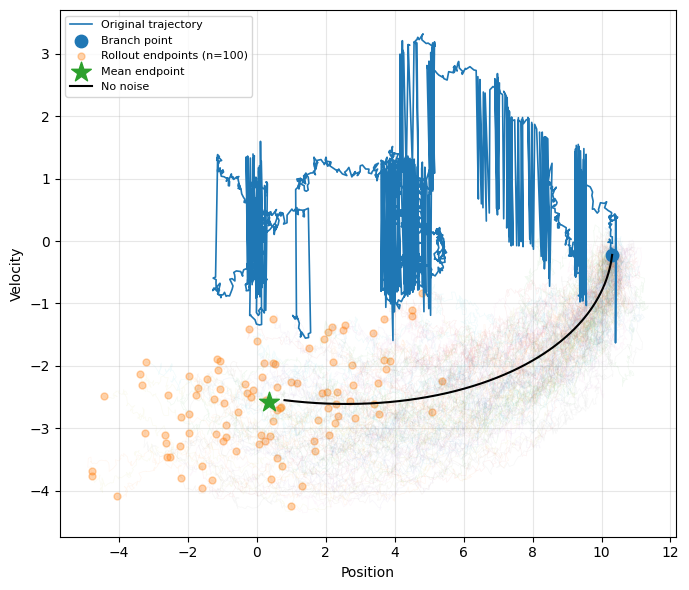

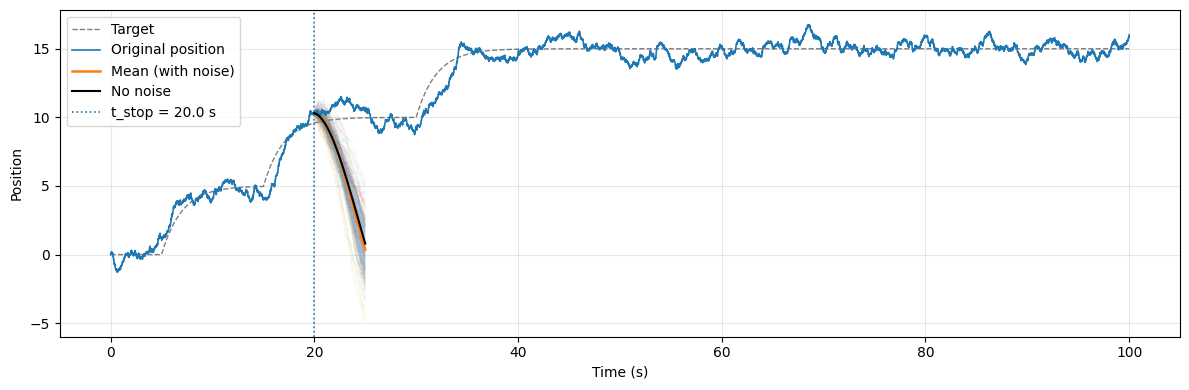

Branch point: 10.31
Mean endpoint: 0.35 ± 2.33
No-noise endpoint: 0.8


In [9]:
# Monte-Carlo rollout from a fixed branch point
t_stop    = 20.0    # time at which trajectories branch
n_samples = 100     # number of noisy rollouts
roll_len  = 500     # rollout length (steps)

stop_idx    = min(int(t_stop / dt), len(t_eval) - 2)
actual_roll = min(roll_len, len(t_eval) - stop_idx - 1)
t_roll      = t_eval[stop_idx : stop_idx + actual_roll + 1]

x0_mc = x[stop_idx].copy()
V0_mc = V_arr[stop_idx].copy()
z0_mc = z[stop_idx]

all_pos = np.zeros((n_samples, actual_roll + 1))
all_vel = np.zeros((n_samples, actual_roll + 1))

for trial in range(n_samples):
    rng = np.random.default_rng(trial)
    xi  = x0_mc.copy()
    Vi  = V0_mc.copy()
    zi  = z0_mc
    all_pos[trial, 0] = xi[0]
    all_vel[trial, 0] = xi[1]
    for k in range(actual_roll):
        t_k = t_roll[k]
        target_vec = np.array([zi, 0.0])

        z_base_k = 0.0
        for t_point, val in z_schedule:
            if t_k >= t_point:
                z_base_k = val
        target_dot_vec = np.array([0.5 * (z_base_k - zi), 0.0])

        xm   = xi + sigma_m * rng.standard_normal(N)
        s    = np.zeros(N)

        xi = xi + dt * (A @ xi) + B @ s              + sigma_p * rng.standard_normal(N) * np.sqrt(dt)
        Vd = -Vi + G @ (target_dot_vec + target_vec) - F_mat @ xm
        Vi = Vi + dt * Vd - Omega @ s              + sigma_v * np.sqrt(dt) * rng.standard_normal(N)
        zi = zi + dt * 0.5 * (z_base_k - zi)

        all_pos[trial, k+1] = xi[0]
        all_vel[trial, k+1] = xi[1]


xi_det = x0_mc.copy()
Vi_det = V0_mc.copy()
zi_det = z0_mc
det_pos = np.zeros(actual_roll + 1)
det_vel = np.zeros(actual_roll + 1)
det_pos[0] = xi_det[0]
det_vel[0] = xi_det[1]
for k in range(actual_roll):
    t_k = t_roll[k]
    target_vec = np.array([zi_det, 0.0])
    z_base_k = 0.0
    for t_point, val in z_schedule:
        if t_k >= t_point:
            z_base_k = val
    target_dot_vec = np.array([0.5 * (z_base_k - zi_det), 0.0])
    xi_det = xi_det + dt * (A @ xi_det)
    Vi_det = Vi_det + dt * (-Vi_det + G @ (target_dot_vec + target_vec) - F_mat @ xi_det)
    zi_det = zi_det + dt * 0.5 * (z_base_k - zi_det)
    det_pos[k+1] = xi_det[0]
    det_vel[k+1] = xi_det[1]

mean_pos = all_pos.mean(axis=0)
std_pos  = all_pos.std(axis=0)
mean_vel = all_vel.mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x[:stop_idx+1, 0], x[:stop_idx+1, 1],lw=1.2, label='Original trajectory', zorder=3)
ax.scatter(*x[stop_idx], s=80, zorder=5, label='Branch point')
for i in range(n_samples):
    ax.plot(all_pos[i], all_vel[i],alpha=0.06, lw=0.5)
ax.scatter(all_pos[:, -1], all_vel[:, -1], alpha=0.35, s=25, label=f'Rollout endpoints (n={n_samples})')
ax.scatter(mean_pos[-1], mean_vel[-1], marker='*', s=220, zorder=6, label='Mean endpoint')
ax.plot(det_pos, det_vel, color='black', lw=1.5, zorder=7, label='No noise')
z_end = z[stop_idx + actual_roll]
ax.set_xlabel('Position'); ax.set_ylabel('Velocity')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_eval, z, 'k--', alpha=0.5, lw=1, label='Target')
ax.plot(t_eval, x[:, 0], lw=1.2,
        label='Original position', zorder=3)
for i in range(n_samples):
    ax.plot(t_roll, all_pos[i], alpha=0.07, lw=0.6)
ax.fill_between(t_roll, mean_pos - std_pos, mean_pos + std_pos, alpha=0.30)
ax.plot(t_roll, mean_pos, lw=1.8, label='Mean (with noise)')
ax.plot(t_roll, det_pos, color='black', lw=1.5, zorder=7, label='No noise')
ax.axvline(t_stop, lw=1.2, linestyle=':', label=f't_stop = {t_stop:.1f} s')
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Position')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Branch point:", round(x0_mc[0], 2))
print("Mean endpoint:", round(mean_pos[-1],2), "±", round(std_pos[-1], 2))
print("No-noise endpoint:", round(det_pos[-1], 2))